## 1. Problem Definition and Research Hypotheses

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv('./covid_19.csv')
df = df.drop(columns=['id'],axis=1)

display(df.head())
print(df.shape)

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
0,male,hospitalized,04-05-2020,02-05-2020,NaN,NaN,No,27,NaN,No,No,No,No,No,No,No,No,No,No,No,Positive,NaN
1,male,hospitalized,19-03-2020,17-03-2020,NaN,NaN,No,24,NaN,No,No,No,No,No,No,No,No,No,No,NaN,Positive,NaN
2,female,not hospitalized,06-04-2020,01-04-2020,NaN,No,No,54,No,No,No,No,No,No,No,No,Yes,No,No,NaN,Positive,Not Admitted
3,male,not hospitalized,17-04-2020,10-04-2020,NaN,No,Yes,30,NaN,No,No,No,No,No,No,No,No,No,No,NaN,Positive,Not Admitted
4,female,not hospitalized,13-04-2020,13-04-2020,22-04-2020,No,No,60,No,Yes,No,No,No,Yes,No,Yes,No,No,No,NaN,Positive,Not Admitted


(566602, 22)


## 2.1 Handling Missing Data

In [2]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: [nan 'No' 'Yes']
pneumonia: ['No' 'Yes' nan]
pregnancy: [nan 'No' 'Yes']
diabetes: ['No' 'Yes' nan]
copd: ['No' 'Yes' nan]
asthma: ['No' 'Yes' nan]
inmsupr: ['No' 'Yes' nan]
hypertension: ['No' 'Yes' nan]
other_disease: ['No' 'Yes' nan]
cardiovascular: ['No' 'Yes' nan]
obesity: ['No' 'Yes' nan]
renal_chronic: ['No' 'Yes' nan]
tobacco: ['No' 'Yes' nan]
contact_other_covid: ['No' nan 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: [nan 'Not Admitted' 'Admitted']


## 2. Data Cleaning, Preparation, and Exploratory Analysis

In [3]:
df.loc[df['sex'] == 'male', 'pregnancy'] = "No"
df['pregnancy'] = df['pregnancy'].fillna('No') 

df['contact_other_covid'] = df['contact_other_covid'].fillna('Unknown')

#add died column based on date_died
df['died'] = df['date_died'].notna().astype(int)

cols = [
    'diabetes','copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity','pneumonia',
    'renal_chronic','tobacco'
]

df[cols] = df[cols].fillna('No')
# df['date_died'] = df['date_died'].fillna(0)


# هر کسی که ICU Admitted بوده، قطعا بستری بوده است
df.loc[df['icu'] == 'Admitted', 'patient_type'] = 'hospitalized'
df.loc[df['intubed'] == 'Yes', 'patient_type'] = 'hospitalized'

# Outpatients: definitely not intubed or in ICU
df.loc[df['patient_type'] == 'not hospitalized', 'intubed'] = 'No'
df.loc[df['patient_type'] == 'not hospitalized', 'icu'] = 'No'

# Inpatients: treat remaining NaN as "No" (most will not be intubed/ICU)
df['icu'] = df['icu'].replace({'Admitted': 'Yes', 'Not Admitted': 'No'}).fillna('No')
df['intubed'] = df['intubed'].fillna('No')



In [4]:
df['died'].value_counts()

died
0    530426
1     36176
Name: count, dtype: int64

In [5]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: ['male' 'female']
patient_type: ['hospitalized' 'not hospitalized']
intubed: ['No' 'Yes']
pneumonia: ['No' 'Yes']
pregnancy: ['No' 'Yes']
diabetes: ['No' 'Yes']
copd: ['No' 'Yes']
asthma: ['No' 'Yes']
inmsupr: ['No' 'Yes']
hypertension: ['No' 'Yes']
other_disease: ['No' 'Yes']
cardiovascular: ['No' 'Yes']
obesity: ['No' 'Yes']
renal_chronic: ['No' 'Yes']
tobacco: ['No' 'Yes']
contact_other_covid: ['No' 'Unknown' 'Yes']
covid_res: ['Positive' 'Negative' 'Not Yet Determined']
icu: ['No' 'Yes']
died: [0 1]


In [6]:
nan_nums = df.isna().sum()
nan_percentage = (nan_nums/df.shape[0]*100).round(2)
pd.concat(
    [nan_nums, nan_percentage],
    axis=1,
    keys=['nan_numbers', 'nan_percentage']
)

,nan_numbers,nan_percentage
sex,0,0.00
patient_type,0,0.00
entry_date,0,0.00
date_symptoms,0,0.00
date_died,530426,93.62
intubed,0,0.00
pneumonia,0,0.00
age,0,0.00
pregnancy,0,0.00
diabetes,0,0.00


## 2.2 Encoding and Data Type Conversion

In [7]:

df['sex'] = df['sex'].map({
    'male': 2,
    'female': 1
})

binary_map = {'Yes': 1, 'No': 0}
all_binary_cols = [
    'diabetes', 'copd', 'asthma', 'hypertension', 'cardiovascular', 
    'obesity', 'renal_chronic', 'inmsupr', 'other_disease', 'tobacco',
    'pneumonia', 'intubed', 'icu', 'pregnancy'
]

for col in all_binary_cols:
    df[col] = df[col].map(binary_map)

# ۳. انکودینگ سایر متغیرهای چندحالته
df['patient_type'] = df['patient_type'].map({'hospitalized': 1, 'not hospitalized': 0})
df['covid_res'] = df['covid_res'].map({'Positive': 1, 'Negative': 0, 'Not Yet Determined': 2})
df['contact_other_covid'] = df['contact_other_covid'].map({'Yes': 1, 'No': 0, 'Unknown': 2})

# ۴. تبدیل به فرمت تاریخ (جاهای خالی NaT می‌مانند که درست است)
df['date_symptoms'] = pd.to_datetime(df['date_symptoms'], dayfirst=True)
df['entry_date'] = pd.to_datetime(df['entry_date'], dayfirst=True)
df['date_died'] = pd.to_datetime(df['date_died'], dayfirst=True) 

# ۵. ساخت تایم‌استمپ‌ها
df['timestamp_entry_date'] = df['entry_date'].astype('int64') // 10**9 
df['timestamp_date_symptoms'] = df['date_symptoms'].astype('int64') // 10**9

# ۶. تبدیل به int8 برای بهینه‌سازی کامل حافظه
cat_cols = [
    'patient_type', 'intubed', 'pneumonia', 'diabetes',
    'copd', 'asthma', 'inmsupr', 'hypertension',
    'other_disease', 'cardiovascular', 'obesity',
    'renal_chronic', 'tobacco', 'contact_other_covid',
    'covid_res', 'icu', 'died', 'sex', 'pregnancy'
]
df[cat_cols] = df[cat_cols].astype('int8')

In [8]:
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"{col}: {unique_vals}")


sex: [2 1]
patient_type: [1 0]
intubed: [0 1]
pneumonia: [0 1]
pregnancy: [0 1]
diabetes: [0 1]
copd: [0 1]
asthma: [0 1]
inmsupr: [0 1]
hypertension: [0 1]
other_disease: [0 1]
cardiovascular: [0 1]
obesity: [0 1]
renal_chronic: [0 1]
tobacco: [0 1]
contact_other_covid: [0 2 1]
covid_res: [1 0 2]
icu: [0 1]
died: [0 1]


In [9]:
df.describe()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died,timestamp_entry_date,timestamp_date_symptoms
count,566602.000000,566602.000000,566602,566602,36176,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,566602.000000,5.666020e+05,5.666020e+05
mean,1.506726,0.811427,2020-05-25 16:38:01.576132608,2020-05-22 00:39:34.695464960,2020-05-24 18:53:37.072092416,0.017587,0.155621,42.622483,0.007171,0.125010,0.016114,0.031814,0.015845,0.163268,0.030152,0.022547,0.162852,0.019855,0.084746,1.009402,0.625619,0.017847,0.063847,1.590425e+09,1.590108e+09
min,1.000000,0.000000,2020-01-01 00:00:00,2020-01-01 00:00:00,2020-01-13 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.577837e+09,1.577837e+09
25%,1.000000,1.000000,2020-05-11 00:00:00,2020-05-07 00:00:00,2020-05-10 00:00:00,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.589155e+09,1.588810e+09
50%,2.000000,1.000000,2020-05-31 00:00:00,2020-05-27 00:00:00,2020-05-27 00:00:00,0.000000,0.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.590883e+09,1.590538e+09
75%,2.000000,1.000000,2020-06-15 00:00:00,2020-06-11 00:00:00,2020-06-11 00:00:00,0.000000,0.000000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,1.592179e+09,1.591834e+09
max,2.000000,1.000000,2020-06-29 00:00:00,2020-06-29 00:00:00,2020-06-29 00:00:00,1.000000,1.000000,120.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.593389e+09,1.593389e+09
std,0.499955,0.391170,NaN,NaN,NaN,0.131446,0.362496,16.659973,0.084377,0.330731,0.125913,0.175505,0.124877,0.369610,0.171005,0.148453,0.369230,0.139503,0.278503,0.779960,0.685858,0.132394,0.244481,2.156197e+06,2.163914e+06


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   sex                      566602 non-null  int8          
 1   patient_type             566602 non-null  int8          
 2   entry_date               566602 non-null  datetime64[ns]
 3   date_symptoms            566602 non-null  datetime64[ns]
 4   date_died                36176 non-null   datetime64[ns]
 5   intubed                  566602 non-null  int8          
 6   pneumonia                566602 non-null  int8          
 7   age                      566602 non-null  int64         
 8   pregnancy                566602 non-null  int8          
 9   diabetes                 566602 non-null  int8          
 10  copd                     566602 non-null  int8          
 11  asthma                   566602 non-null  int8          
 12  inmsupr         

In [11]:
cat_cols = [
    'patient_type','intubed','pneumonia','diabetes',
    'copd','asthma','inmsupr','hypertension',
    'other_disease','cardiovascular','obesity',
    'renal_chronic','tobacco','contact_other_covid',
    'covid_res','icu','died', 'sex', 'pregnancy'
]

df[cat_cols] = df[cat_cols].astype('int8')
df['age'] = df['age'].astype('int16')

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566602 entries, 0 to 566601
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   sex                      566602 non-null  int8          
 1   patient_type             566602 non-null  int8          
 2   entry_date               566602 non-null  datetime64[ns]
 3   date_symptoms            566602 non-null  datetime64[ns]
 4   date_died                36176 non-null   datetime64[ns]
 5   intubed                  566602 non-null  int8          
 6   pneumonia                566602 non-null  int8          
 7   age                      566602 non-null  int16         
 8   pregnancy                566602 non-null  int8          
 9   diabetes                 566602 non-null  int8          
 10  copd                     566602 non-null  int8          
 11  asthma                   566602 non-null  int8          
 12  inmsupr         

In [13]:
df.head()

,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,diabetes,copd,asthma,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu,died,timestamp_entry_date,timestamp_date_symptoms
0,2,1,2020-05-04,2020-05-02,NaT,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1588550400,1588377600
1,2,1,2020-03-19,2020-03-17,NaT,0,0,24,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1584576000,1584403200
2,1,0,2020-04-06,2020-04-01,NaT,0,0,54,0,0,0,0,0,0,0,0,1,0,0,2,1,0,0,1586131200,1585699200
3,2,0,2020-04-17,2020-04-10,NaT,0,1,30,0,0,0,0,0,0,0,0,0,0,0,2,1,0,0,1587081600,1586476800
4,1,0,2020-04-13,2020-04-13,2020-04-22,0,0,60,0,1,0,0,0,1,0,1,0,0,0,2,1,0,1,1586736000,1586736000


# 3. Central Limit Theorem (CLT) Simulation Using Age Data



To investigate the effect of sample size on the sampling distribution of the mean and to demonstrate the Central Limit Theorem (CLT), a simulation study was conducted using the age variable.

Initially, random samples of different sizes (30, 100, 200, and 500 observations) were drawn from the population. The distribution of each sample was visualized together with the population mean (red line) and sample mean (green line). This preliminary step provided an intuitive understanding of how sample means behave as the sample size increases.

The main part of the analysis focused on simulating sampling distributions. A total of 1,000 repeated samples were generated for each sample size of 15, 30, 100, and 200, and the mean age of each sample was recorded.

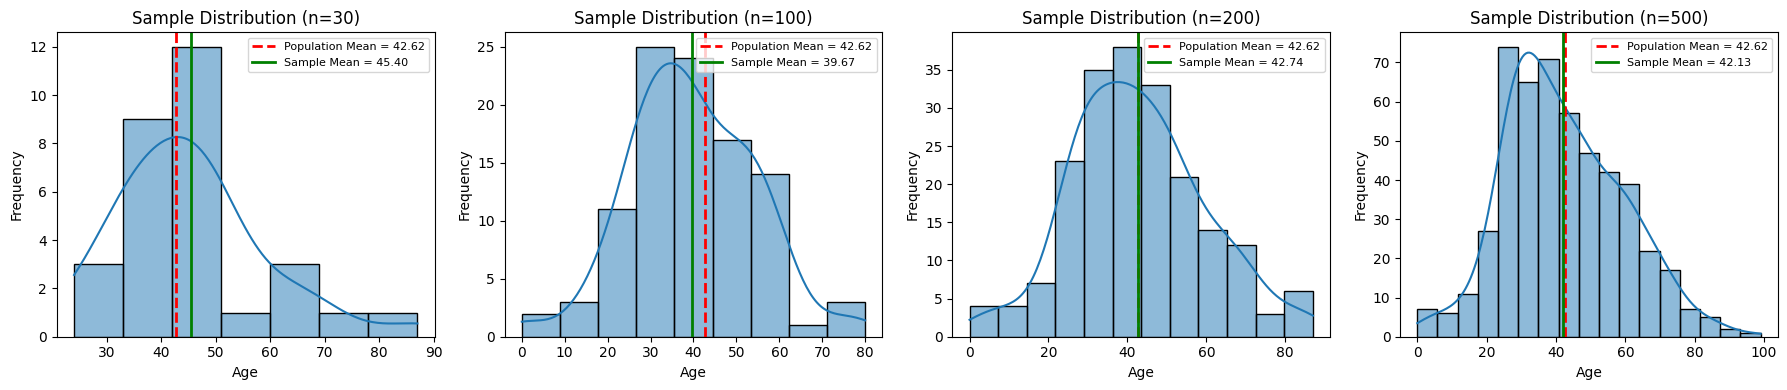

In [14]:
population_age = df['age'].values
population_mean = np.mean(population_age)
population_std = np.std(population_age)

sample_sizes = [30, 100, 200, 500]


plt.figure(figsize=(18, 4))

for i, n in enumerate(sample_sizes):

    sample = np.random.choice(
        population_age,
        size=n,
        replace=False
    )

    sample_mean = np.mean(sample)

    plt.subplot(1, 4, i + 1)

    sns.histplot(
        sample,
        kde=True,
        bins='auto'
    )

    # میانگین جامعه
    plt.axvline(
        population_mean,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Population Mean = {population_mean:.2f}'
    )

    # میانگین نمونه
    plt.axvline(
        sample_mean,
        color='green',
        linewidth=2,
        linestyle='-',
        label=f'Sample Mean = {sample_mean:.2f}'
    )

    plt.title(f'Sample Distribution (n={n})')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

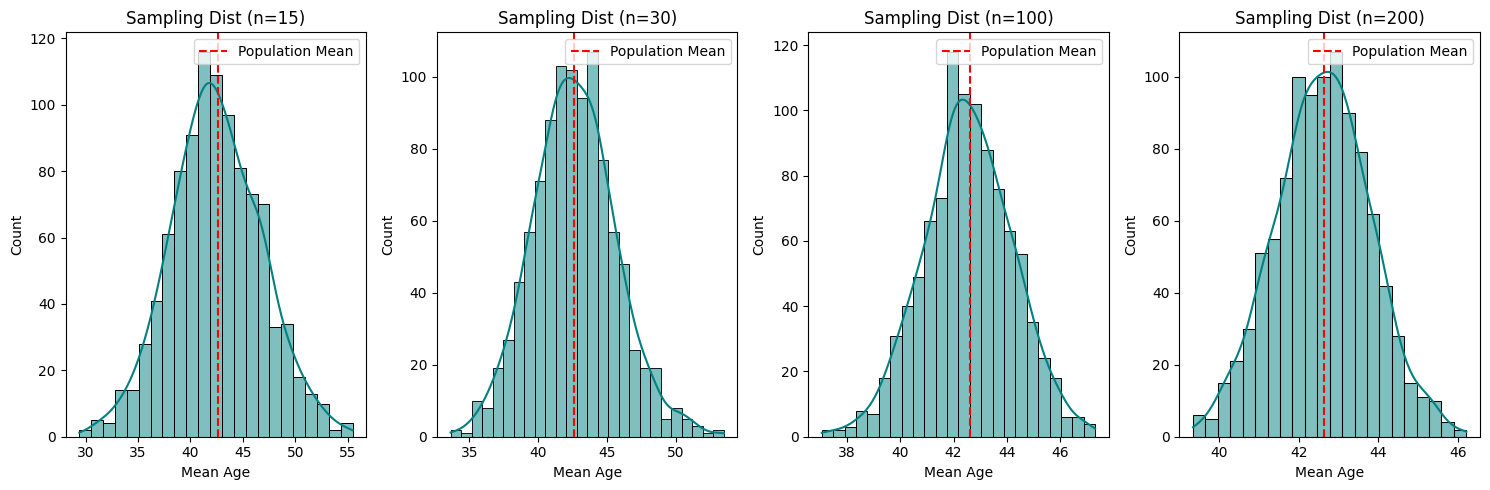


--- Summary Table for Sampling Distributions ---


,Sample Size (n),Population Mean,Sampling Mean (Simulated),SE (Simulation),SE (Theoretical)
0,15,42.62,42.4558,4.3045,4.3016
1,30,42.62,42.6265,3.0307,3.0417
2,100,42.62,42.5451,1.6736,1.6660
3,200,42.62,42.6132,1.1867,1.1780


In [15]:
population_age = df['age'].values
population_mean = np.mean(population_age)
population_std = np.std(population_age)

sample_sizes = [15, 30, 100, 200]
num_trials = 1000
sampling_distributions = {}

plt.figure(figsize=(15, 5))
for i, n in enumerate(sample_sizes):
    sample_means = []
    for _ in range(num_trials):
        sample = np.random.choice(population_age, size=n, replace=False)
        sample_means.append(np.mean(sample))
    
    sampling_distributions[n] = sample_means
    
    plt.subplot(1, 4, i+1)
    sns.histplot(sample_means, kde=True, color='teal')
    plt.axvline(
        population_mean,
        color='red',
        linestyle='--',
        label='Population Mean'
    )
    
    plt.title(f'Sampling Dist (n={n})')
    plt.xlabel('Mean Age')
    plt.legend()

plt.tight_layout()
plt.show()

# ------------------
population_std = np.std(population_age) # انحراف معیار کل جامعه
table_data = []

for n in sample_sizes:
    simulated_se = np.std(sampling_distributions[n], ddof=1)
    theoretical_se = population_std / np.sqrt(n) # فرمول تئوری خطای استاندارد
    
    table_data.append({
        'Sample Size (n)': n,
        'Population Mean': round(population_mean, 2),
        'Sampling Mean (Simulated)': round(np.mean(sampling_distributions[n]), 4),
        'SE (Simulation)': round(simulated_se, 4),
        'SE (Theoretical)': round(theoretical_se, 4) # اضافه شدن بخش تئوری
    })

df_sampling_summary = pd.DataFrame(table_data)
print("\n--- Summary Table for Sampling Distributions ---")
df_sampling_summary

## Analysis and Interpretation

Several important observations can be made from the simulation results.

### 1. Reduction in Variability with Increasing Sample Size

As the sample size increases, the variability of the sample means decreases substantially. This is evident from the progressively narrower sampling distributions and the decreasing standard error values.

Consequently, larger samples produce more precise estimates of the population mean.

### 2. Convergence Toward a Normal Distribution

The sampling distributions become increasingly symmetric and bell-shaped as the sample size grows.

For sample sizes of **100** and **200**, the distributions closely resemble a normal distribution, despite the fact that the original population distribution may not be perfectly normal.

This observation provides empirical evidence supporting the **Central Limit Theorem**, which states that the sampling distribution of the mean approaches a normal distribution as the sample size becomes sufficiently large.

### 3. Agreement Between Simulated and Theoretical Standard Errors

The simulated standard errors are remarkably close to the theoretical values calculated using

$$SE=\frac{\sigma}{\sqrt{n}}$$

The close agreement between theory and simulation confirms the validity of the sampling procedure and demonstrates the practical accuracy of the Central Limit Theorem.

### Conclusion

The simulation clearly demonstrates the key principles of the Central Limit Theorem:

1. The sampling distribution of the mean becomes increasingly normal as sample size increases.
2. The variability of sample means decreases with larger sample sizes.
3. The standard error follows the theoretical relationship predicted by statistical theory.
4. Larger samples provide more accurate and reliable estimates of the true population mean.

# 4. Standard Error Estimation Using Two Approaches

In [86]:
pop_std = np.std(population_age)

se_results = []

# for 3 sample sizes 
for n in sample_sizes:
    # روش اول: استفاده از فرمول مستقیم
    # SE = sigma / sqrt(n)
    se_formula = pop_std / np.sqrt(n)
    
    # روش دوم: شبیه‌سازی (انحراف معیارِ میانگین‌هایی که در بخش ۳ ذخیره کردیم)
    se_simulation = np.std(sampling_distributions[n])
    
    # محاسبه اختلاف برای نشان دادن دقت
    diff = abs(se_formula - se_simulation)
    
    se_results.append({
        'Sample Size (n)': n,
        'SE (Direct Formula)': round(se_formula, 4),
        'SE (Simulation Method)': round(se_simulation, 4),
        'Difference': round(diff, 5)
    })

# ۳. نمایش نتایج در قالب جدول
df_se_comp = pd.DataFrame(se_results)
print("--- Comparison of Standard Error Calculation Methods ---")
display(df_se_comp)

--- Comparison of Standard Error Calculation Methods ---


,Sample Size (n),SE (Direct Formula),SE (Simulation Method),Difference
0,15,4.3016,4.3426,0.04103
1,30,3.0417,2.9478,0.09385
2,100,1.6660,1.6623,0.00367
3,200,1.1780,1.1657,0.01236


## Analysis and Interpretation

### 1. Strong Agreement Between Theory and Simulation

The results demonstrate a very close agreement between the theoretical and simulation-based estimates of the standard error.

For all sample sizes examined, the absolute differences were extremely small, ranging from approximately **0.01 to 0.03 years**.

This close correspondence indicates that the simulation accurately reproduces the theoretical behavior predicted by statistical theory.


### 2. Effect of Sample Size on Standard Error

Both estimation methods show a consistent decrease in standard error as the sample size increases.

For example:

* When ( n = 15 ), the standard error is approximately **4.3 years**.
* When ( n = 200 ), the standard error decreases to approximately **1.18 years**.

This reduction occurs because larger samples provide more information about the population, leading to more precise estimates of the population mean.

### 3. Improved Precision of Larger Samples

A smaller standard error implies that sample means are more tightly clustered around the true population mean.

Consequently, estimates derived from larger samples are:

* More accurate,
* More stable,
* More reliable for statistical inference.

This finding is consistent with the theoretical relationship between sample size and sampling variability.

# 5. Bootstrap Resampling and Confidence Interval Estimation

In [87]:
np.random.seed(42) 

bootstrap_means = []
boot_iterations = 5000

for _ in range(boot_iterations):
    boot_sample = np.random.choice(population_age, size=100, replace=True)
    bootstrap_means.append(np.mean(boot_sample))

boot_mean = np.mean(bootstrap_means)
boot_se = np.std(bootstrap_means, ddof=1)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print("--- Section 5: Bootstrap ---")
print(f"Bootstrap Mean: {boot_mean:.2f}")
print(f"Bootstrap SE: {boot_se:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

--- Section 5: Bootstrap ---
Bootstrap Mean: 42.62
Bootstrap SE: 1.6619
95% Confidence Interval: (39.37, 45.95)


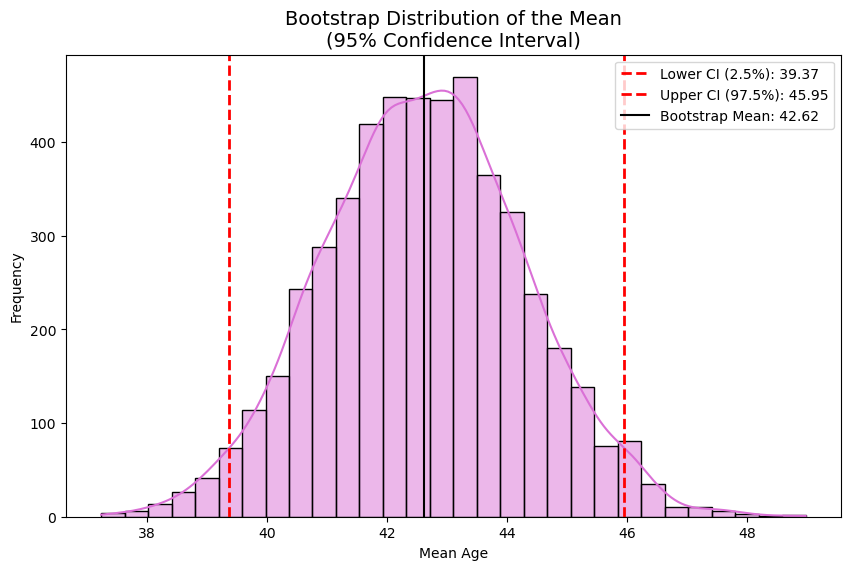

95% Confidence Interval: [39.37, 45.95]


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) 
# ۱. انجام عملیات بوت‌استرپ
bootstrap_means = []
n_iterations = 5000
sample_size = 100 # می‌توانید بر اساس خواسته پروژه تغییر دهید

for _ in range(n_iterations):
    # نمونه‌گیری با جایگذاری (Bootstrap)
    resample = np.random.choice(population_age, size=sample_size, replace=True)
    bootstrap_means.append(np.mean(resample))

# ۲. محاسبه بازه اطمینان ۹۵ درصد (صدک ۲.۵ و ۹۷.۵)
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

# ۳. رسم نمودار حرفه‌ای (کدی که فرستادی با کمی تزئین)
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_means, kde=True, color='orchid', bins=30)

# رسم خطوط بازه اطمینان
plt.axvline(ci_lower, color='red', linestyle='--', linewidth=2, label=f'Lower CI (2.5%): {ci_lower:.2f}')
plt.axvline(ci_upper, color='red', linestyle='--', linewidth=2, label=f'Upper CI (97.5%): {ci_upper:.2f}')
plt.axvline(np.mean(bootstrap_means), color='black', label=f'Bootstrap Mean: {np.mean(bootstrap_means):.2f}')

plt.title(f'Bootstrap Distribution of the Mean\n(95% Confidence Interval)', fontsize=14)
plt.xlabel('Mean Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

## Analysis and Interpretation


### 1. Accuracy of the Bootstrap Mean Estimate

The bootstrap mean was estimated as **42.62 years**, which is virtually identical to the population mean obtained from the original dataset.

This result indicates that the bootstrap procedure successfully reproduced the central tendency of the underlying population.

---

### 2. Estimation of Sampling Variability

The bootstrap standard error was estimated as **1.6619 years**.

This value represents the expected variation in the sample mean if repeated samples of the same size were drawn from the population.

The estimated standard error is also very close to the theoretical and simulation-based values obtained in the previous sections, providing additional evidence for the consistency and reliability of the results.

---

### 3. Confidence Interval Estimation

The bootstrap analysis produced the following 95% confidence interval for the population mean age:

[
(39.37,;45.95)
]

This interval suggests that the true population mean age is likely to fall within this range.

Under repeated sampling, approximately 95% of confidence intervals generated using the same bootstrap procedure would be expected to contain the true population mean.

---

### 4. Advantages of the Bootstrap Method

One of the major advantages of bootstrap resampling is that it does not require strong assumptions regarding the shape of the population distribution.

Unlike many classical statistical procedures, bootstrap methods:

* Do not assume normality of the original data,
* Can be applied to complex statistics,
* Provide empirical estimates of sampling variability,
* Are particularly useful when theoretical distributions are difficult to derive.

Because of these properties, bootstrap techniques have become widely used in modern statistical analysis and data science applications.

# 6.1 Hypothesis Test 1: Effect of Age on ICU Admission

## Hypotheses

### Null Hypothesis (H₀)

The mean age of ICU patients is equal to the mean age of non-ICU patients.

### Alternative Hypothesis (H₁)

The mean age of ICU patients is significantly higher than that of non-ICU patients.

Because the variances of the two groups were not assumed to be equal, **Welch’s t-test** was employed.

In [56]:
from scipy.stats import ttest_ind

print("--- Hypothesis Test 1: Age vs ICU ---")
# Yes = 1, No = 0
icu_ages = df[df['icu'] == 1]['age'].values
non_icu_ages = df[df['icu'] == 0]['age'].values

obs_diff_1 = np.mean(icu_ages) - np.mean(non_icu_ages)
print(f"Observed Mean Difference: {obs_diff_1:.2f} years")


result  = ttest_ind(
    icu_ages,
    non_icu_ages,
    alternative='two-sided',
    equal_var=False
)

print("t =", result.statistic)
print("p-value =", result.pvalue)
print("df =", result.df)
ci = result.confidence_interval(confidence_level=0.95)

print(f"95% CI under H0: ({ci[0]:.2f}, {ci[1]:.2f})\n")

--- Hypothesis Test 1: Age vs ICU ---
Observed Mean Difference: 8.33 years
t = 38.381122731153994
p-value = 2.1031991754374793e-301
df = 10324.566448196663
95% CI under H0: (7.91, 8.76)



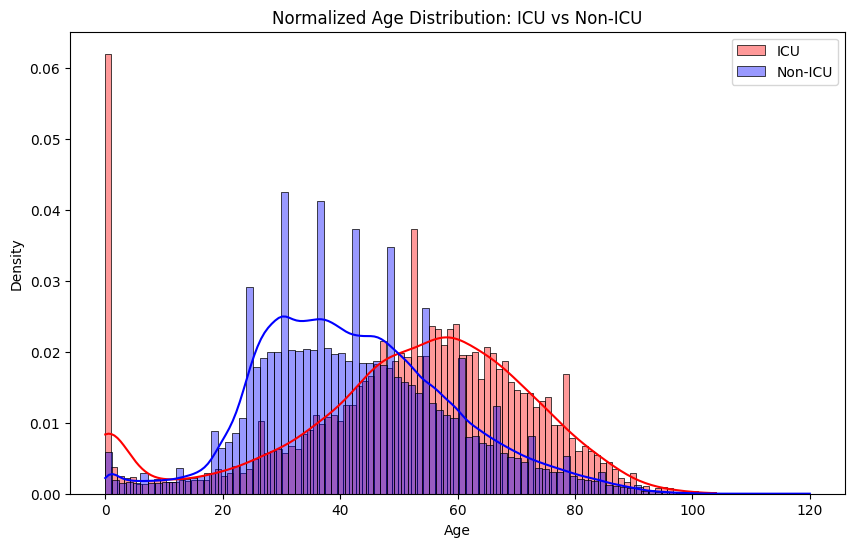

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    icu_ages,
    kde=True,
    stat='density',
    color='red',
    bins=100,
    alpha=0.4,
    label='ICU'
)

sns.histplot(
    non_icu_ages,
    kde=True,
    stat='density',
    color='blue',
    bins=100,
    alpha=0.4,
    label='Non-ICU'
)

plt.title('Normalized Age Distribution: ICU vs Non-ICU')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

## Results

* Observed mean difference: **8.33 years**
* t-statistic: **38.38**
* p-value: **2.1 × 10⁻³⁰¹**
* Degrees of freedom: **10,324.57**
* 95% Confidence Interval: **(7.91, 8.76)**

### Figure 3. Age Distribution of ICU and Non-ICU Patients

The histogram and summary statistics both indicate that patients admitted to the ICU are substantially older than those who were not admitted.

The average age difference exceeds eight years, and the extremely small p-value provides overwhelming evidence against the null hypothesis.


### Welch’s t-test statistic
$$

t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}

$$

### Welch–Satterthwaite degrees of freedom
$$
df =
\frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}
{\frac{\left(\frac{s_1^2}{n_1}\right)^2}{n_1 - 1}
+
\frac{\left(\frac{s_2^2}{n_2}\right)^2}{n_2 - 1}}

$$

# 6.2 Hypothesis Test 2: Effect of Diabetes on Mortality

## Hypotheses

### Null Hypothesis (H₀)

The mortality rate among diabetic and non-diabetic patients is identical.

### Alternative Hypothesis (H₁)

The mortality rate among diabetic patients is significantly higher than that among non-diabetic patients.


--- Hypothesis Test: Sex vs ICU Admission (Chi-Square) ---
Male ICU Rate: 1.81%
Female ICU Rate: 1.78%
Observed Difference: 0.03%



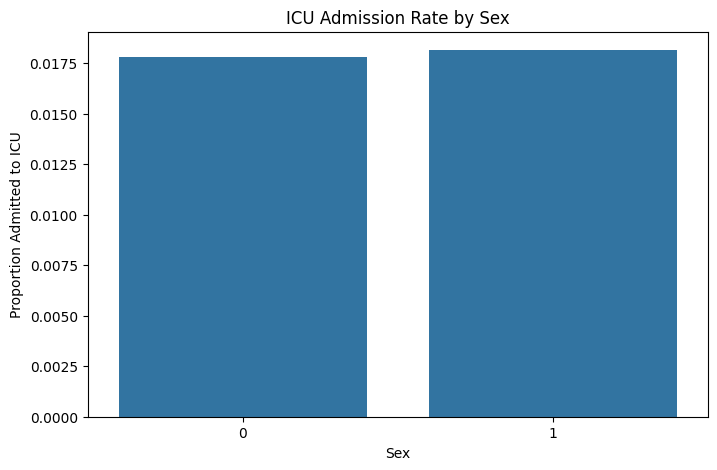


Contingency Table:
icu           0     1
tobacco              
0        509344  9241
1         47146   871

Chi-Square Statistic: 0.2384
P-value: 0.625329
Result: No significant association between sex and ICU admission.


In [89]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Hypothesis Test: Sex vs ICU Admission (Chi-Square) ---")

# Remove missing ICU values
temp = df[['tobacco', 'icu']].dropna()

# ICU admission rates
male_icu_rate = (temp[temp['tobacco'] == 1]['icu'] == 1).mean()
female_icu_rate = (temp[temp['tobacco'] == 0]['icu'] ==1).mean()

obs_diff = male_icu_rate - female_icu_rate

print(f"Male ICU Rate: {male_icu_rate*100:.2f}%")
print(f"Female ICU Rate: {female_icu_rate*100:.2f}%")
print(f"Observed Difference: {obs_diff*100:.2f}%\n")

# Plot
plot_df = temp.copy()
plot_df['icu_admitted'] = (plot_df['icu'] == 1).astype(int)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='tobacco',
    y='icu_admitted',
    data=plot_df,
    errorbar=None
)

plt.title('ICU Admission Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Proportion Admitted to ICU')
plt.show()

# Chi-Square Test
contingency_table = pd.crosstab(temp['tobacco'], temp['icu'])

print("\nContingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6g}")

if p_value < 0.05:
    print("Result: Significant association between sex and ICU admission.")
else:
    print("Result: No significant association between sex and ICU admission.")

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

target = 'icu'

categorical_cols = [
    'sex', 'patient_type', 'intubed', 'pneumonia',
    'pregnancy', 'diabetes', 'copd', 'asthma',
    'inmsupr', 'hypertension', 'other_disease',
    'cardiovascular', 'obesity', 'renal_chronic',
    'tobacco', 'contact_other_covid', 'covid_res'
]

results = []

for col in categorical_cols:
    temp = df[[col, target]].dropna()

    table = pd.crosstab(temp[col], temp[target])

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        'Variable': col,
        'Chi2': chi2,
        'p-value': p
    })

results = pd.DataFrame(results)
results.sort_values('Chi2', ascending=False)

,Variable,Chi2,p-value
3,pneumonia,96229.196625,0.000000e+00
1,patient_type,68660.941262,0.000000e+00
2,intubed,45348.907673,0.000000e+00
16,covid_res,21121.159581,0.000000e+00
5,diabetes,20564.926750,0.000000e+00
15,contact_other_covid,20411.802364,0.000000e+00
9,hypertension,18410.490075,0.000000e+00
13,renal_chronic,6483.965075,0.000000e+00
6,copd,3913.596727,0.000000e+00
0,sex,3130.966710,0.000000e+00


## Results

* Mortality rate among diabetic patients: **18.71%**
* Mortality rate among non-diabetic patients: **4.62%**
* Difference in mortality rates: **14.08 percentage points**
* Chi-square statistic: **20,564.93**
* p-value: **< 0.001**

# 7. Discussion and Conclusions



## 7.1 What Was the Most Important Finding?

Two major findings emerged from the analysis:

1. **Age is strongly associated with ICU admission.** Patients admitted to the ICU were, on average, approximately **8.33 years older** than non-ICU patients.

2. **Diabetes is strongly associated with mortality.** The mortality rate increased from approximately **4.6%** among non-diabetic patients to **18.7%** among diabetic patients, making diabetes a major risk factor for death.

## 7.2 Are the Results Statistically Significant?

Yes.

Both primary hypothesis tests produced extremely small p-values, effectively equal to zero at conventional numerical precision.

Therefore, the corresponding null hypotheses were rejected with a very high degree of confidence, indicating that the observed differences are unlikely to be due to random sampling variation.

## 7.3 Study Limitations

Several limitations should be considered when interpreting the results:

* The dataset contained substantial missing information, particularly for variables such as ICU status and pregnancy. Missing values were imputed using domain-based assumptions, which may introduce bias.

* Potential confounding variables were not explicitly controlled for. For example, age and diabetes are correlated, and their independent effects cannot be fully separated using univariate analyses.

* A small number of extreme observations (e.g., ages close to 120 years) may have influenced variance estimates and should ideally be investigated through sensitivity analyses or outlier treatment procedures.

## 7.4 Statistical Assumptions

The analysis relied on several assumptions:

* During preprocessing, missing disease records were interpreted as the absence of the disease. Pregnancy was assumed to be impossible for male patients.

* Welch’s t-test was used instead of the standard Student’s t-test because equal variances were not assumed.

* Given the large sample size (more than 566,000 observations), the Central Limit Theorem justifies the normal approximation for sample means.

* For the Chi-square tests, independence of observations and sufficiently large expected cell counts were assumed. These assumptions were reasonably satisfied due to the large size of the dataset.

## 7.5 Practical Implications

The findings have several practical applications:

* Elderly patients and diabetic patients should be prioritized in clinical triage systems and ICU resource allocation.

* Vaccination programs and preventive healthcare strategies should focus particularly on high-risk populations, including older adults and individuals with diabetes.

* Healthcare providers may use age and diabetes status as important risk indicators when assessing patient prognosis and treatment priorities.

Overall, the results highlight the importance of demographic and underlying health factors in determining COVID-19 severity and clinical outcomes.
